In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('demand_forecasting.csv')

df.head()

Saving demand_forecasting.csv to demand_forecasting.csv


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [2]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [3]:
df = df.drop(columns=['Date'])
df = pd.get_dummies(df, drop_first=True)

df.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand,Store ID_S002,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,195,102,252,72.72,5,0,85.73,0,115,False,...,False,True,False,False,False,True,False,False,False,True
1,117,117,249,80.16,15,1,92.02,0,229,False,...,False,True,False,False,False,True,False,False,False,True
2,247,114,612,62.94,10,1,60.08,0,157,False,...,False,True,False,False,False,True,False,False,False,True
3,139,45,102,87.63,10,0,85.19,0,52,False,...,False,True,False,False,False,True,False,False,False,True
4,152,65,271,54.41,0,0,51.63,0,59,False,...,False,True,False,False,False,True,False,False,False,True


In [6]:
X = df.drop(columns=['Demand'])
y = df['Demand']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [9]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [10]:
predictions = lm.predict(X_test)

In [11]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2 Score:', metrics.r2_score(y_test, predictions))

MAE: 16.378827874289726
MSE: 488.83951811750654
RMSE: 22.109715468940493
R2 Score: 0.7793102330671344


In [12]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Inventory Level,-0.012263
Units Sold,0.651406
Units Ordered,0.047938
Price,0.178043
Discount,0.104682
Promotion,10.389153
Competitor Pricing,0.013307
Epidemic,-17.038461
Store ID_S002,-0.649951
Store ID_S003,0.205913


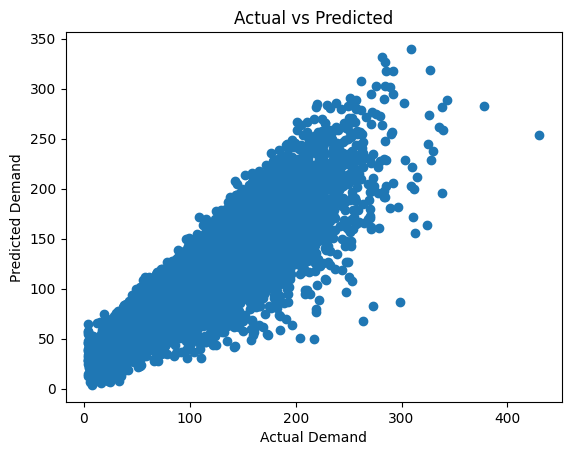

In [14]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted')
plt.show()

<Axes: xlabel='Demand', ylabel='Count'>

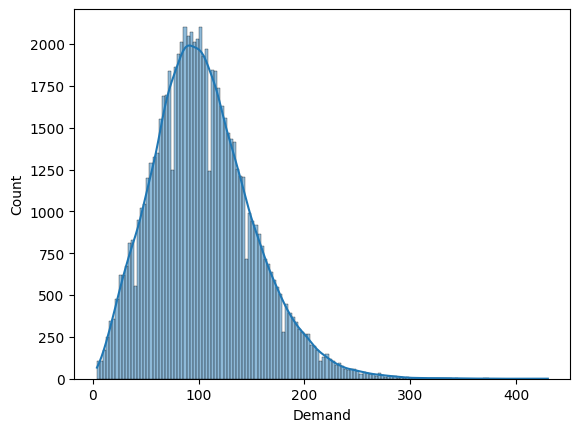

In [23]:
sns.histplot(df['Demand'], kde=True)

<Axes: >

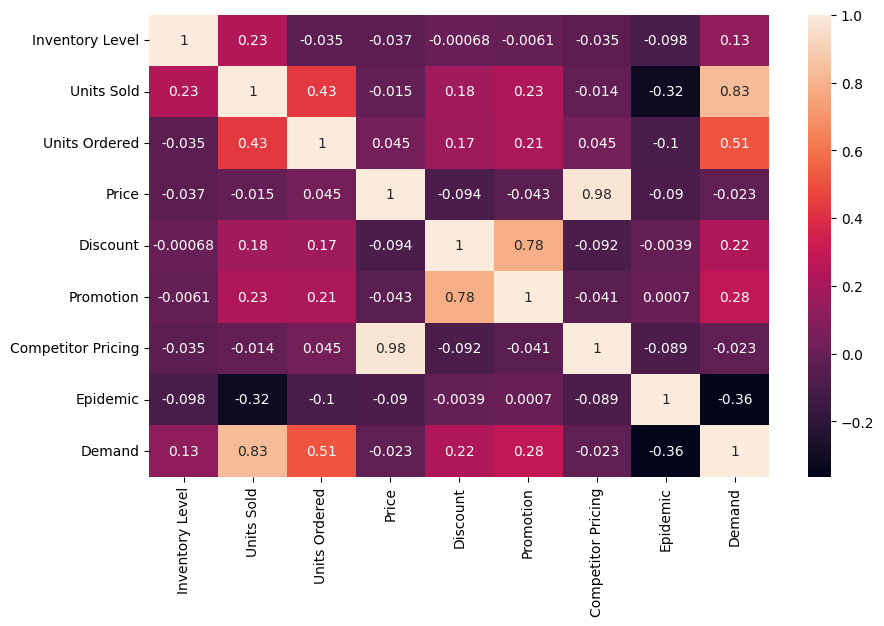

In [26]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)